<a href="https://colab.research.google.com/github/a1247418/EGEM/blob/main/Per_digt_EGEM_24_06_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load MNIST

In [ ]:
'''
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='/content/drive/MyDrive/Master thesis/MNIST/dataset_modified', train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root='/content/drive/MyDrive/Master thesis/MNIST/dataset_modified', train=False, download=True)
'''

"\nimport torchvision\nimport torchvision.transforms as transforms\nfrom PIL import Image\nimport numpy as np\n\ntransform = transforms.ToTensor()\ntrain_dataset = torchvision.datasets.MNIST(root='/content/drive/MyDrive/Master thesis/MNIST/dataset_modified', train=True, download=True)\ntest_dataset = torchvision.datasets.MNIST(root='/content/drive/MyDrive/Master thesis/MNIST/dataset_modified', train=False, download=True)\n"

In [ ]:
'''
from torchvision.datasets.mnist import read_image_file, read_label_file
import torch

raw_path = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified/MNIST/raw"
processed_path = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified/MNIST/processed"

# Decompression train dataset
train_data = read_image_file(f"{raw_path}/train-images-idx3-ubyte")
train_labels = read_label_file(f"{raw_path}/train-labels-idx1-ubyte")
torch.save((train_data, train_labels), f"{processed_path}/training.pt")

# Decompression test dataset
test_data = read_image_file(f"{raw_path}/t10k-images-idx3-ubyte")
test_labels = read_label_file(f"{raw_path}/t10k-labels-idx1-ubyte")
torch.save((test_data, test_labels), f"{processed_path}/test.pt")
'''

'\nfrom torchvision.datasets.mnist import read_image_file, read_label_file\nimport torch\n\nraw_path = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified/MNIST/raw"\nprocessed_path = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified/MNIST/processed"\n\n# Decompression train dataset\ntrain_data = read_image_file(f"{raw_path}/train-images-idx3-ubyte")\ntrain_labels = read_label_file(f"{raw_path}/train-labels-idx1-ubyte")\ntorch.save((train_data, train_labels), f"{processed_path}/training.pt")\n\n# Decompression test dataset\ntest_data = read_image_file(f"{raw_path}/t10k-images-idx3-ubyte")\ntest_labels = read_label_file(f"{raw_path}/t10k-labels-idx1-ubyte")\ntorch.save((test_data, test_labels), f"{processed_path}/test.pt")\n'

In [ ]:
'''
from torchvision.datasets import MNIST

dataset_dir = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified"

# Load train dataset
train_dataset = MNIST(root=dataset_dir, train=True)
print(f"The size of train dataset: {len(train_dataset)}")  # Output 60000

# Load test dataset
test_dataset = MNIST(root=dataset_dir, train=False)
print(f"The size of test dataset: {len(test_dataset)}")  # Output 10000
'''

'\nfrom torchvision.datasets import MNIST\n\ndataset_dir = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified"\n\n# Load train dataset\ntrain_dataset = MNIST(root=dataset_dir, train=True)\nprint(f"The size of train dataset: {len(train_dataset)}")  # Output 60000\n\n# Load test dataset\ntest_dataset = MNIST(root=dataset_dir, train=False)\nprint(f"The size of test dataset: {len(test_dataset)}")  # Output 10000\n'

----------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Prepare original model and datasets

In [ ]:
!pip install torchmetrics

from torchmetrics import Accuracy
import os, sys
import numpy as np
import torch
from matplotlib import pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torch.utils.data import ConcatDataset, DataLoader
import copy

module_path = '/content/drive/MyDrive/Master thesis/MNIST/CH_datasets-main'
if module_path not in sys.path:
    sys.path.append(module_path)

#from CH_datasets.scenario_examples import get_scenario
from CH_datasets.utils import plot_scenario
from CH_datasets.scenario_examples_per_digt import get_scenario

  Using cached torchmetrics-1.7.3-py3-none-any.whl.metadata (21 kB)
  Using cached lightning_utilities-0.14.3-py3-none-any.whl.metadata (5.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.wh

## Getting Dataset

* Normal datasets
  * train_loader (80% poisioned)
  * refinement_loader (used for refining all classes)
  * test_loader (100% poisioned)
***
* Normal datasets nonpoisioned
  * test_0poisioned_loader
***
* Refinement Dataset on class 0
  * refinement_loader_list[0]
* Refinement Dataset on class 1
  * refinement_loader_list[1]
* Refinement Dataset on class 2
  * refinement_loader_list[2]
* Refinement Dataset on class 3
  * refinement_loader_list[3]
* Refinement Dataset on class 4
  * refinement_loader_list[4]
* Refinement Dataset on class 5
  * refinement_loader_list[5]
* Refinement Dataset on class 6
  * refinement_loader_list[6]
* Refinement Dataset on class 7
  * refinement_loader_list[7]
* Refinement Dataset on class 8
  * refinement_loader_list[8]
* Refinement Dataset on class 9
  * refinement_loader_list[9]


### Get poisioned dataset(80% poisioned), refinement dataset(0% posioned) and test dataset(100% poisioned and 0% poisioned)

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Master thesis/MNIST/dataset_modified
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Master thesis/MNIST/dataset_modified
    Split: Test


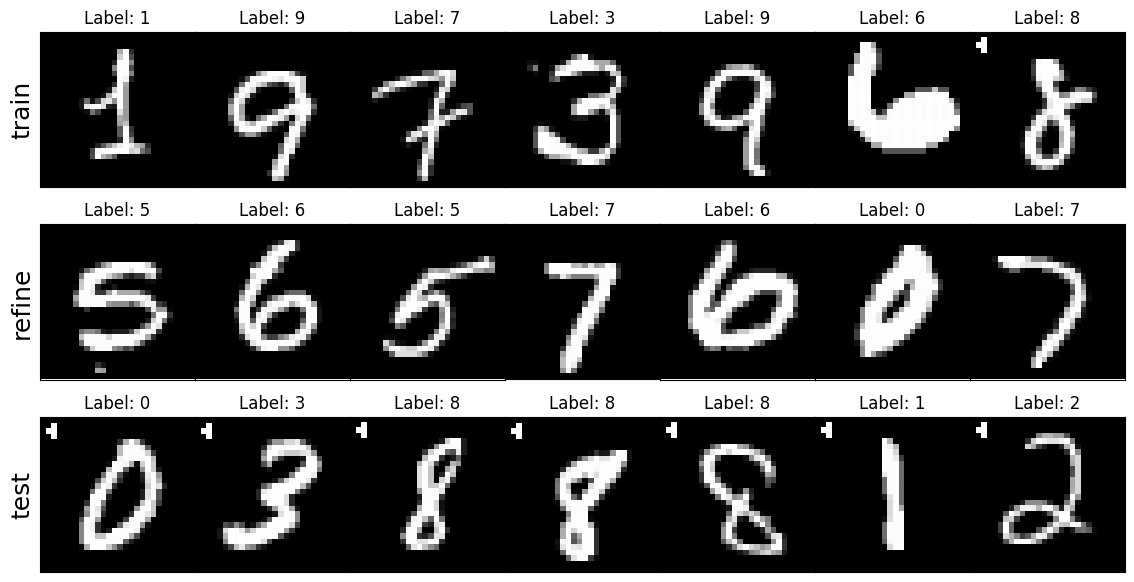

Dataset MNIST
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Master thesis/MNIST/dataset_modified
    Split: Test


In [ ]:
mnist_path = "/content/drive/MyDrive/Master thesis/MNIST/dataset_modified"
target_class = [8]
background_classes = list(set([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) - set(target_class))

scenario_per_digt = get_scenario("mnist-per-digt", dataset_path=mnist_path, normalize=False,
                  target_class=target_class, background_classes=background_classes, train_p=0.8) # 80% poisioned train dataset
datas = []
for split in ["train", "refine", "test"]:
    datas.append(scenario_per_digt.get_data(split))
    print(scenario_per_digt.get_data(split))
plot_scenario(*datas, color_map="gray")

# Get 0% poisioned test dataset
scenario_per_digt_nonpoisioned = get_scenario("mnist-per-digt", dataset_path=mnist_path, normalize=False,
                        target_class=target_class, background_classes=background_classes, test_p=0) # test_p=0
datas = []
datas.append(scenario_per_digt_nonpoisioned.get_data("test"))
print(scenario_per_digt_nonpoisioned.get_data("test"))
#plot_scenario(*datas, color_map="gray")
train_dataset_per_digt = scenario_per_digt.get_train_data()  # Returns training dataset
refinement_dataset_per_digt = scenario_per_digt.get_refine_data()  # Returns refinement dataset
test_dataset_per_digt = scenario_per_digt.get_test_data()  # Returns test dataset
test_dataset_per_digt_nonpoisioned = scenario_per_digt_nonpoisioned.get_test_data()  # Returns test dataset

### Get Refinement Dataset on Every Class

In [ ]:
refinement_dataset_list = []
for i in range(10):
  # Get refinement dataset on only 8 and the rest
  indices = torch.where(refinement_dataset_per_digt.dataset.targets[refinement_dataset_per_digt.indices] == i)[0]
  rest_indices = torch.where(refinement_dataset_per_digt.dataset.targets[refinement_dataset_per_digt.indices] != i)[0]


  refinement_dataset = Subset(refinement_dataset_per_digt, indices)
  refinement_dataset_list.append(refinement_dataset)
  #refinement_dataset_rest = Subset(refinement_dataset_per_digt, rest_indices)

  # Combine train and test dataset in case there are enough data to test
  #test_dataset_8 = ConcatDataset([train_dataset_8, test_dataset_8])

In [ ]:
# Check the number of images in each subset
for i, subset in enumerate(refinement_dataset_list):
    print(f"Number of images in refinement_dataset_list[{i}]: {len(subset)}")

Number of images in refinement_dataset_list[0]: 5643
Number of images in refinement_dataset_list[1]: 1652
Number of images in refinement_dataset_list[2]: 2849
Number of images in refinement_dataset_list[3]: 4518
Number of images in refinement_dataset_list[4]: 3201
Number of images in refinement_dataset_list[5]: 3231
Number of images in refinement_dataset_list[6]: 5183
Number of images in refinement_dataset_list[7]: 4578
Number of images in refinement_dataset_list[8]: 4998
Number of images in refinement_dataset_list[9]: 4089


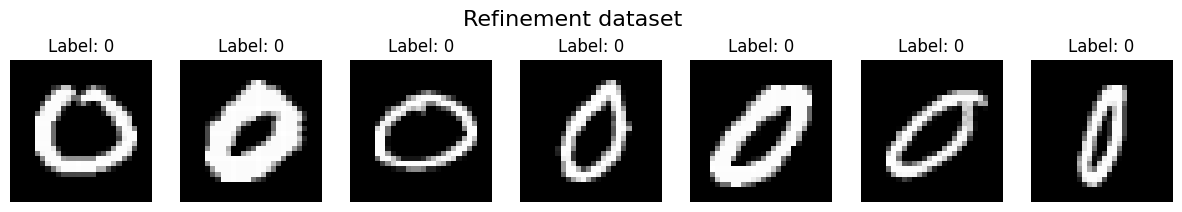

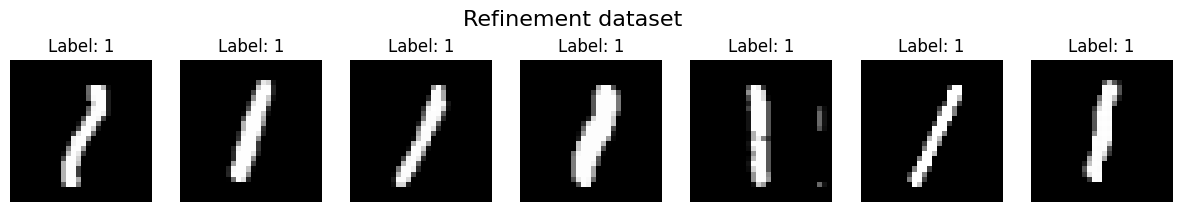

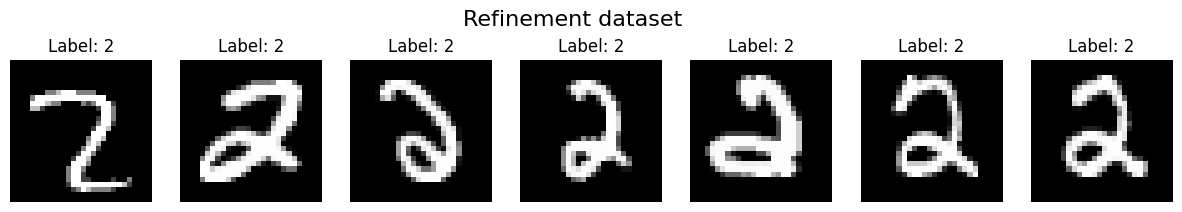

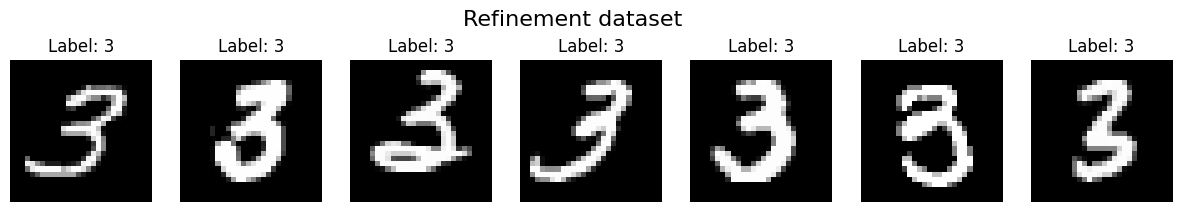

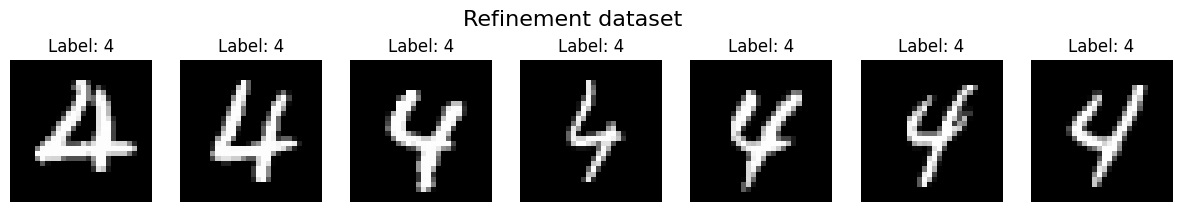

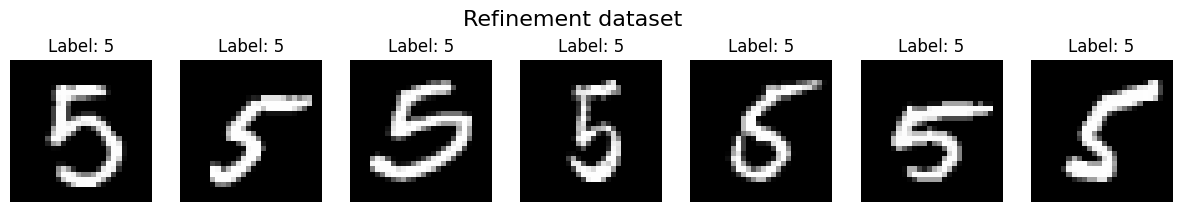

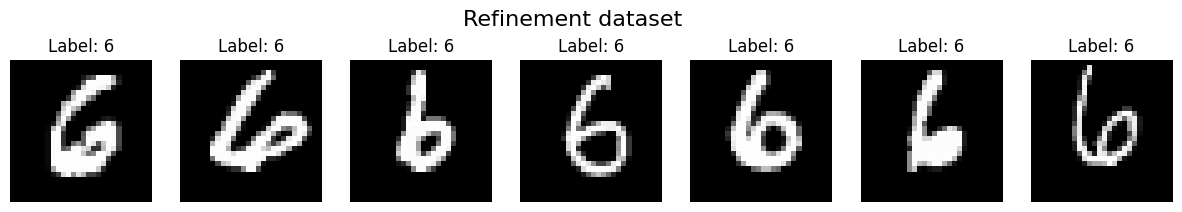

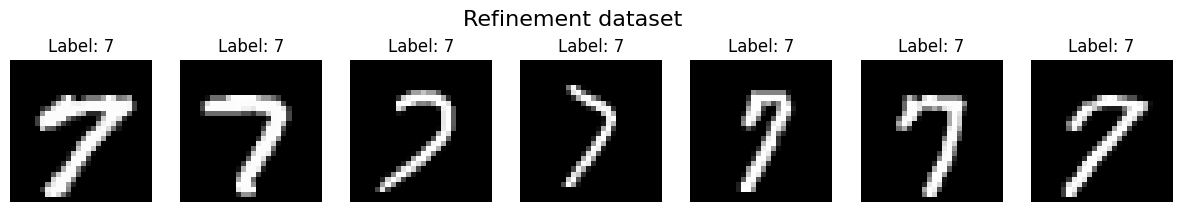

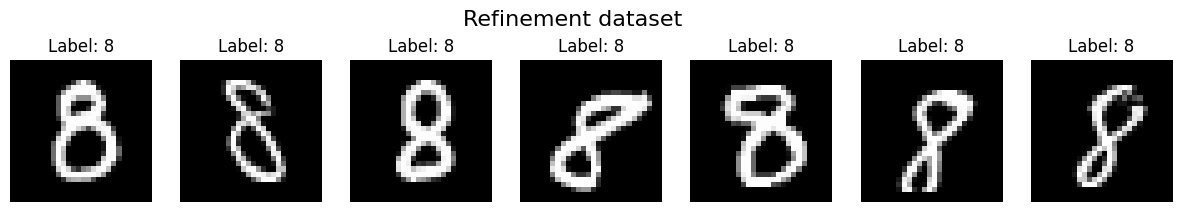

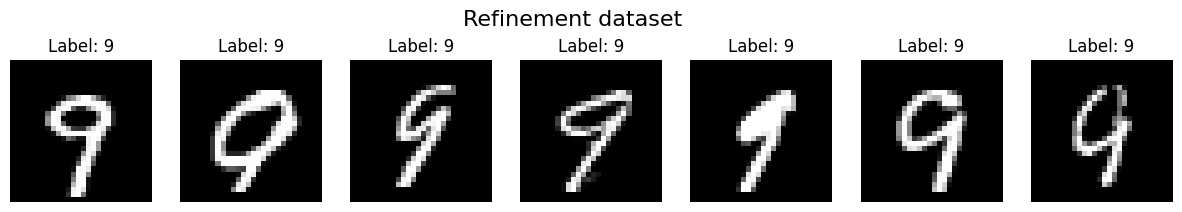

In [ ]:
# Visualisation
def visualize_random_samples(dataset, title):
    indices = torch.randint(0, len(dataset), (7,))
    samples = [dataset[i] for i in indices]

    images, labels = zip(*samples)

    # Plot fig
    fig, axes = plt.subplots(1, 7, figsize=(15, 2.5))
    fig.suptitle(title, fontsize=16)
    for i, (image, label) in enumerate(zip(images, labels)):
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

# Datasets for only 8
for i in range(10):
  visualize_random_samples(refinement_dataset_list[i], "Refinement dataset")


### Loading Dataset

In [ ]:
# Define relevant variables for the ML task
batch_size = 32
num_classes = 10
learning_rate = 0.001
num_epochs = 5

# Device will determine whether to run the training on GPU or CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
train_loader = torch.utils.data.DataLoader(dataset = train_dataset_per_digt,
                       batch_size = batch_size,
                       shuffle = True)

refinement_loader = torch.utils.data.DataLoader(dataset = refinement_dataset,
                         batch_size = batch_size,
                         shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset = test_dataset_per_digt,
                      batch_size = batch_size,
                      shuffle = True)
# Loading refinement datasets
refinement_loader_list = []
for i in range(10):
  refinement_dataset = refinement_dataset_list[i]
  refinement_loader_per_digt = torch.utils.data.DataLoader(dataset = refinement_dataset,
                         batch_size = batch_size,
                         shuffle = True)
  refinement_loader_list.append(refinement_loader_per_digt)

# Nonpoisioned test dataset
test_0poisioned_loader = torch.utils.data.DataLoader(dataset = test_dataset_per_digt_nonpoisioned,
                            batch_size = batch_size,
                            shuffle = True)


## Methods

In [ ]:
# Training model
def train_model(model, train_loader, num_epochs=10, optimizer=torch.optim.Adam, cost=nn.CrossEntropyLoss(), learning_rate=0.001):
  optimizer = optimizer(model.parameters(), lr=learning_rate)
  total_step = len(train_loader)

  model.train()
  for epoch in range(num_epochs):
    for j, (images, labels) in enumerate(train_loader):
      images = images.to(device)
      labels = labels.to(device)

      #Forward pass
      outputs = model(images) #Refine the model on refinement dataset
      loss = cost(outputs, labels)
      #Backward and optimize
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if (j+1) % total_step == 0:
        print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
            .format(epoch+1, num_epochs, j+1, total_step, loss.item()))

In [ ]:
# Testing model
def test_model(model, test_loader):
    acc = Accuracy(
        task = "multiclass",
        num_classes = 10
    ).to(device)

    model.eval()
    with torch.no_grad():
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        acc(predicted, labels)

    acc = acc.compute()
    return (acc.item()*100)

# Register hooks to get activation values
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

## Defining the LeNet5 Model

In [ ]:
#Defining the convolutional neural network
class LeNet5(nn.Module):
    def __init__(self, num_classes):
        super(LeNet5, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(6),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(256, 120)
        self.relu = nn.LeakyReLU(negative_slope=0.01)
        self.fc1 = nn.Linear(120, 84)
        self.relu1 = nn.LeakyReLU(negative_slope=0.01)
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc1(out)
        out = self.relu1(out)
        out = self.fc2(out)
        return out

### Loading original model

In [ ]:
'''
model = LeNet5(num_classes).to(device)
train_model(model,train_loader, num_epochs=10)
test_acc = test_model(model, test_loader)
print("Test accuracy: {}%".format(test_acc))
test_acc_nonpoisioned = test_model(model, test_0poisioned_loader)
print("Test accuracy nonpoisioned: {}%".format(test_acc_nonpoisioned))
'''

'\nmodel = LeNet5(num_classes).to(device)\ntrain_model(model,train_loader, num_epochs=10)\ntest_acc = test_model(model, test_loader)\nprint("Test accuracy: {}%".format(test_acc))\ntest_acc_nonpoisioned = test_model(model, test_0poisioned_loader)\nprint("Test accuracy nonpoisioned: {}%".format(test_acc_nonpoisioned))\n'

In [ ]:
#torch.save(model.state_dict(),
#        "/content/drive/MyDrive/Master thesis/EGEM_Model_History/model_per_dict.pth")

In [ ]:
model = LeNet5(num_classes).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model.pth"))
test_acc = test_model(model, test_loader)
print("Test accuracy: {}%".format(test_acc))
test_acc_nonpoisioned = test_model(model, test_0poisioned_loader)
print("Test accuracy nonpoisioned: {}%".format(test_acc_nonpoisioned))


Test accuracy: 89.68999981880188%
Test accuracy nonpoisioned: 98.72000217437744%


# Original EGEM

### Get activitation values

In [ ]:
'''
c: Dictonary, 10 elements, depends on the number of lamda
|-c_layer1_value: Tensor
|-c_layer2_value: Tensor
|-c_fc_value: Tensor
|-c_fc1_value: Tensor
'''
# Set lambda
lambda_param_s = np.linspace(0, 1, 10)
lambda_param_list = lambda_param_s.tolist()

# Loading the original model
model = LeNet5(num_classes).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model.pth"))
model.eval()

c = {}

for i, lambda_param in enumerate(lambda_param_list):
  # Define the dictionary to store the activation value
  activations = {}
  a_fc_list = []
  a_fc1_list = []
  a_layer1_list = []
  a_layer2_list = []

  # Hook list
  hook_handles = []
  # Register forward hook function to the target and store handles
  hook_handles.append(model.layer1[2].register_forward_hook(get_activation("layer1_leakyrelu_output")))
  hook_handles.append(model.layer2[2].register_forward_hook(get_activation("layer2_leakyrelu_output")))
  hook_handles.append(model.relu.register_forward_hook(get_activation("relu")))
  hook_handles.append(model.relu1.register_forward_hook(get_activation("relu1")))

  # Define input data
  with torch.no_grad():
    for image, _ in refinement_loader:
      image = image.to(device)

      # Forward
      output = model(image)

      # Get activitation
      a_fc = activations["relu"]
      a_fc1 = activations["relu1"]
      a_layer1 = activations["layer1_leakyrelu_output"]
      a_layer2 = activations["layer2_leakyrelu_output"]
      a_fc_list.append(a_fc)
      a_fc1_list.append(a_fc1)
      a_layer1_list.append(a_layer1)
      a_layer2_list.append(a_layer2)

  # --- clear hooks ---
  for handle in hook_handles:
    handle.remove()
  ##
  # Get average activation values
  a_layer1 = torch.cat(a_layer1_list, dim=0)
  a_layer2 = torch.cat(a_layer2_list, dim=0)
  a_fc = torch.cat(a_fc_list, dim=0)
  a_fc1 = torch.cat(a_fc1_list, dim=0)

  # Get activitation values of each layer
  a_layer1_squared_mean = torch.mean(a_layer1**2, dim=[0, 2, 3])
  a_layer2_squared_mean = torch.mean(a_layer2**2, dim=[0, 2, 3])
  a_fc_squared_mean = torch.mean(a_fc**2, dim=0)
  a_fc1_squared_mean = torch.mean(a_fc1**2, dim=0)

  # Calculate edited activitation values
  c_layer1_value = (a_layer1_squared_mean)/(lambda_param + a_layer1_squared_mean)
  c_layer2_value = (a_layer2_squared_mean)/(lambda_param + a_layer2_squared_mean)
  c_fc_value = (a_fc_squared_mean)/(lambda_param + a_fc_squared_mean)
  c_fc1_value = (a_fc1_squared_mean)/(lambda_param + a_fc1_squared_mean)


  # Storing the set of c values on every activation layer
  c[i] = [c_layer1_value, c_layer2_value, c_fc_value, c_fc1_value]

  print("{}/{} done!".format(i+1, len(lambda_param_list)))
print("The size of c list:",len(c_list))


1/10 done!
2/10 done!
3/10 done!
4/10 done!
5/10 done!
6/10 done!
7/10 done!
8/10 done!
9/10 done!
10/10 done!
The size of c list: 10


### EGEM for all classes

In [ ]:
#Defining the convolutional neural network
class modified_LeNet5(nn.Module):
    def __init__(self, original_model, scaling_factors_list):
        super(modified_LeNet5, self).__init__()
        # 分解 layer1 的组件
        self.conv1 = original_model.layer1[0]
        self.bn1 = original_model.layer1[1]
        self.leakyrelu1_orig = original_model.layer1[2] # LeakyReLU from layer1
        self.pool1 = original_model.layer1[3]

        # 分解 layer2 的组件
        self.conv2 = original_model.layer2[0]
        self.bn2 = original_model.layer2[1]
        self.leakyrelu2_orig = original_model.layer2[2] # LeakyReLU from layer2
        self.pool2 = original_model.layer2[3]

        self.fc = original_model.fc
        self.relu = original_model.relu
        self.fc1 = original_model.fc1
        self.relu1 = original_model.relu1
        self.fc2 = original_model.fc2

        self.scaling_factors_dict = scaling_factors_dict

    def forward_EGEM_all(self, x):
      # Layer1
      out = self.conv1(x)
      out = self.bn1(out)
      out = self.leakyrelu1_orig(out)
      out = out * self.scaling_factors_list[0].view(1, -1, 1, 1) # Scale activiation values of Layer1
      out = self.pool1(out)
      # Layer2
      out = self.conv2(out)
      out = self.bn2(out)
      out = self.leakyrelu2_orig(out)
      out = out * self.scaling_factors_list[1].view(1, -1, 1, 1) # Scale activiation values of Layer2
      out = self.pool2(out)
      # Flatten
      out = out.reshape(out.size(0), -1)
      # FC
      out = self.fc(out)
      out = self.relu(out)
      out = out * self.scaling_factors_list[2].view(1, -1) # Scale activiation values of Fc
      out = self.fc1(out)
      out = self.relu1(out)
      out = out * self.scaling_factors_list[3].view(1, -1) # Scale activiation values of Fc1
      out = self.fc2(out)
      return out

    def forward_EGEM_8(self, x):
      out = 0
      return out

    def forward_EGEM_rest(self, x):
      # Layer1
      out = self.conv1(x)
      out = self.bn1(out)
      out = self.leakyrelu1_orig(out)
      out = self.pool1(out)
      # Layer2
      out = self.conv2(out)
      out = self.bn2(out)
      out = self.leakyrelu2_orig(out)
      out = self.pool2(out)
      # Flatten
      out = out.reshape(out.size(0), -1)
      # FC
      out = self.fc(out)
      out = self.relu(out)
      out = self.fc1(out)
      out = self.relu1(out)
      out = self.fc2(out)
      return out



In [ ]:
def test_modified_model(
    model,
    lambda_param_list: list,
    c_list: list,
    test_loader,
    test_0poisioned_loader: list = None,
    test_class_list: list = [],
    device=device
):
  # Generating every lambda in lambda list
  # Original EGEM
  if test_class_list == []:
    acc_list = []
    for i in range(len(lambda_param_list)):
      # Test refined model on poisioned dataset
      acc = Accuracy(task="multiclass", num_classes=10).to(device)
      modified_model = modified_LeNet5(model, c_list[i]).to(device)
      modified_model.eval()

      for image, label in test_loader: # Testing modified model
        image = image.to(device)
        label = label.to(device)
        with torch.no_grad():
          output_all = modified_model.forward_EGEM_all(image) # Getting the output from original forward
          _, predicted = torch.max(output_all.data, 1)
          acc(predicted, label)
      acc = acc.compute()
      acc = acc.item()*100
      acc_list.append(acc)
    # Test refined model on nonpoisioned dataset
    if test_0poisioned_loader != None:
      acc_list_nonpoisioned = []
      for i in range(len(lambda_param_list)):
        acc = Accuracy(task="multiclass", num_classes=10).to(device)
        modified_model = modified_LeNet5(model, c_list[i]).to(device)
        #modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth".format(i)))
        modified_model.eval()

        for image, label in test_0poisioned_loader: # Testing modified model
          image = image.to(device)
          label = label.to(device)
          with torch.no_grad():
            output_all = modified_model.forward_EGEM_all(image) # Getting the output from original forward
            _, predicted = torch.max(output_all.data, 1)
            acc(predicted, label)
        acc = acc.compute()
        acc = acc.item()*100
        acc_list_nonpoisioned.append(acc)

  else:
    acc_list = []
    for i in range(len(lambda_param_list)):
      acc = Accuracy(task="multiclass", num_classes=10).to(device)
      modified_model = modified_LeNet5(model, c_list[i]).to(device)
      #modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth".format(i)))
      modified_model.eval()

      for image, label in test_loader: # Testing modified model
        image = image.to(device)
        label = label.to(device)
        with torch.no_grad():
          output_all = modified_model.forward_EGEM_rest(image) # Getting the output from original forward
          for test_class in test_class_list: # Getting the output from specific forwards
            out_put = getattr(modified_model, "forward_EGEM_{}".format(test_class))(image)
            output_all[:, test_class] = out_put[:, test_class] # Changing the output list
          _, predicted = torch.max(output_all.data, 1)
          acc(predicted, label)

      acc = acc.compute()
      acc = acc.item()*100
      acc_list.append(acc)

    if test_0poisioned_loader != None:
      acc_list_nonpoisioned = []
      for i in range(len(lambda_param_list)):
        acc = Accuracy(task="multiclass", num_classes=10).to(device)
        modified_model = modified_LeNet5(model, c_list[i]).to(device)
        #modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth".format(i)))
        modified_model.eval()

        for image, label in test_0poisioned_loader: # Testing modified model
          image = image.to(device)
          label = label.to(device)
          with torch.no_grad():
            output_all = modified_model.forward_EGEM_rest(image) # Getting the output from original forward
            for test_class in test_class_list: # Getting the output from specific forwards
              out_put = getattr(modified_model, "forward_EGEM_{}".format(test_class))(image)
              output_all[:, test_class] = out_put[:, test_class] # Changing the output list
            _, predicted = torch.max(output_all.data, 1)
            acc(predicted, label)

        acc = acc.compute()
        acc = acc.item()*100
        acc_list_nonpoisioned.append(acc)

  return acc_list, acc_list_nonpoisioned

### Test original EGEM model

In [ ]:
model = LeNet5(num_classes).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model.pth"))

<All keys matched successfully>

In [ ]:
acc_list = []
for i in range(len(lambda_param_list)):
  # Test refined model on poisioned dataset
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i]).to(device)
  modified_model.eval()

  for image, label in test_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward_EGEM_all(image) # Getting the output from original forward
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list.append(acc)

# Test refined model on nonpoisioned dataset
acc_list_nonpoisioned = []
for i in range(len(lambda_param_list)):
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  modified_model = modified_LeNet5(model, c_list[i]).to(device)
  #modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth".format(i)))
  modified_model.eval()

  for image, label in test_0poisioned_loader: # Testing modified model
    image = image.to(device)
    label = label.to(device)
    with torch.no_grad():
      output_all = modified_model.forward_EGEM_all(image) # Getting the output from original forward
      _, predicted = torch.max(output_all.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_list_nonpoisioned.append(acc)

In [ ]:
acc_list

[89.68999981880188,
 66.56000018119812,
 54.32000160217285,
 39.160001277923584,
 30.52000105381012,
 22.57000058889389,
 13.660000264644623,
 10.350000113248825,
 10.090000182390213,
 10.090000182390213]

In [ ]:
model = LeNet5(num_classes).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model.pth"))

<All keys matched successfully>

In [ ]:
acc_original_poisioned_avgs = []
acc_original_0poisioned_avgs = []

# The results of rest classes for original model
acc_original_poisioned_avgs.append(test_model(model, test_loader))
acc_original_0poisioned_avgs.append(test_model(model, test_0poisioned_loader))

for i, lambda_param in enumerate(lambda_param_list[:-1]): # c_8
    acc_original_poisioned_avgs.append(acc_original_poisioned_avgs[0])
    acc_original_0poisioned_avgs.append(acc_original_0poisioned_avgs[0])

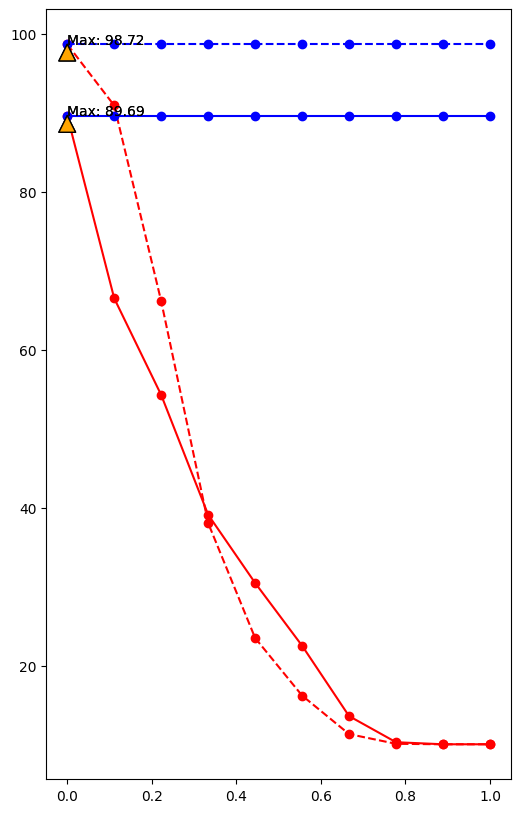

In [ ]:
# Test class 5
acc_EGEM_poisioned_list, acc_EGEM_nonpoisioned_list = test_modified_model(
    model,
    lambda_param_list,
    c_list,
    test_loader,
    test_0poisioned_loader,
    test_class_list=[],
    device=device
)

# acc_EGEM_poisioned
# acc_EGEM_nonpoisioned
# acc_original_poisioned_avgs
# acc_original_0poisioned_avgs

fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_EGEM_poisioned_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_poisioned_list)
max_val = acc_EGEM_poisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_EGEM_nonpoisioned_list, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_nonpoisioned_list)
max_val = acc_EGEM_nonpoisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


plt.show()

# Per-Digt EGEM


## Refine the Model with Refinement Dataset for every class

In [ ]:
for i in range(10):
  # Loading the original model
  refined_model = LeNet5(num_classes).to(device)
  refined_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model.pth"))

  #this is defined to print how many steps are remaining when training
 # total_step = len(refinement_loader_list[i])
 # cost = nn.CrossEntropyLoss()

  # Training model
  train_model(refined_model, refinement_loader_list[i], num_epochs=5, learning_rate=0.0001)
  torch.save(refined_model.state_dict(),
        "/content/drive/MyDrive/Master thesis/EGEM_Model_History/refined_model_{}.pth"
        .format(i))
  print("Model {} done!".format(i+1))

Epoch [1/5], Step [177/177], Loss: 0.0000
Epoch [2/5], Step [177/177], Loss: 0.0000
Epoch [3/5], Step [177/177], Loss: 0.0000
Epoch [4/5], Step [177/177], Loss: 0.0000
Epoch [5/5], Step [177/177], Loss: 0.0000
Model 1 done!
Epoch [1/5], Step [52/52], Loss: 0.3697
Epoch [2/5], Step [52/52], Loss: 0.0597
Epoch [3/5], Step [52/52], Loss: 0.0641
Epoch [4/5], Step [52/52], Loss: 0.0029
Epoch [5/5], Step [52/52], Loss: 0.0011
Model 2 done!
Epoch [1/5], Step [90/90], Loss: 0.0000
Epoch [2/5], Step [90/90], Loss: 0.0000
Epoch [3/5], Step [90/90], Loss: 0.0000
Epoch [4/5], Step [90/90], Loss: 0.0000
Epoch [5/5], Step [90/90], Loss: 0.0000
Model 3 done!
Epoch [1/5], Step [142/142], Loss: 0.0000
Epoch [2/5], Step [142/142], Loss: 0.0000
Epoch [3/5], Step [142/142], Loss: 0.0000
Epoch [4/5], Step [142/142], Loss: 0.0000
Epoch [5/5], Step [142/142], Loss: 0.0000
Model 4 done!
Epoch [1/5], Step [101/101], Loss: 0.0000
Epoch [2/5], Step [101/101], Loss: 0.0000
Epoch [3/5], Step [101/101], Loss: 0.000

## Get activitation values

In [ ]:
'''
c_per_digt_list: List, 10 elements, depends on the number of lamda
|-c_per_digt: Dict, 10 elements, depends on the number of classes
  |-c_layer1_value: Tensor
  |-c_layer2_value: Tensor
  |-c_fc_value: Tensor
  |-c_fc1_value: Tensor
'''
# Set lambda
lambda_param_s = np.linspace(0, 1, 10)
lambda_param_list = lambda_param_s.tolist()

# Get activitation values
c_per_digt_list = []

for j, lambda_param in enumerate(lambda_param_list):
  # Set soft pruning parameter c, [0,1]
  c_per_digt = {}

  for i in range(num_classes):
    # Define the dictionary to store the activation value
    activations = {}
    a_fc_list = []
    a_fc1_list = []
    a_layer1_list = []
    a_layer2_list = []

    if i in [5, 6, 7, 8]:
      #loading the refined model
      refined_model = LeNet5(num_classes).to(device)
      refined_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/refined_model_{}.pth".format(i)))
    else:
      #Loading the original model
      refined_model = LeNet5(num_classes).to(device)
      refined_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model_per_dict.pth"))
    # Hook list
    hook_handles = []
    # Register forward hook function to the target and store handles
    hook_handles.append(refined_model.layer1[2].register_forward_hook(get_activation("layer1_leakyrelu_output")))
    hook_handles.append(refined_model.layer2[2].register_forward_hook(get_activation("layer2_leakyrelu_output")))
    hook_handles.append(refined_model.relu.register_forward_hook(get_activation("relu")))
    hook_handles.append(refined_model.relu1.register_forward_hook(get_activation("relu1")))

    # Define input data
    refined_model.eval()
    with torch.no_grad():
      for image, _ in refinement_loader_list[i]:
        image = image.to(device)

        # Forward
        output = refined_model(image)

        # Get activitation
        a_fc = activations["relu"]
        a_fc1 = activations["relu1"]
        a_layer1 = activations["layer1_leakyrelu_output"]
        a_layer2 = activations["layer2_leakyrelu_output"]
        a_fc_list.append(a_fc)
        a_fc1_list.append(a_fc1)
        a_layer1_list.append(a_layer1)
        a_layer2_list.append(a_layer2)

    # --- clear hooks ---
    for handle in hook_handles:
        handle.remove()
    ##
    # Get average activation values
    a_layer1 = torch.cat(a_layer1_list, dim=0)
    a_layer2 = torch.cat(a_layer2_list, dim=0)
    a_fc = torch.cat(a_fc_list, dim=0)
    a_fc1 = torch.cat(a_fc1_list, dim=0)

    # Get activitation values of each layer
    a_layer1_squared_mean = torch.mean(a_layer1**2, dim=[0, 2, 3])
    a_layer2_squared_mean = torch.mean(a_layer2**2, dim=[0, 2, 3])
    a_fc_squared_mean = torch.mean(a_fc**2, dim=0)
    a_fc1_squared_mean = torch.mean(a_fc1**2, dim=0)

    # Calculate edited activitation values
    c_fc_value = (a_fc_squared_mean)/(lambda_param + a_fc_squared_mean)
    c_fc1_value = (a_fc1_squared_mean)/(lambda_param + a_fc1_squared_mean)
    c_layer1_value = (a_layer1_squared_mean)/(lambda_param + a_layer1_squared_mean)
    c_layer2_value = (a_layer2_squared_mean)/(lambda_param + a_layer2_squared_mean)
    c_per_digt[i] = [c_layer1_value, c_layer2_value, c_fc_value, c_fc1_value]
    ##
  c_per_digt_list.append(c_per_digt)
  print("{}/{} done!".format(j+1, len(lambda_param_list)))
print("The size of c list:",len(c_per_digt_list))


1/10 done!
2/10 done!
3/10 done!
4/10 done!
5/10 done!
6/10 done!
7/10 done!
8/10 done!
9/10 done!
10/10 done!
The size of c list: 10


## EGEM for every single class

In [ ]:
#Defining the convolutional neural network
class modified_LeNet5(nn.Module):
    def __init__(self, original_model, scaling_factors_dict):
        super(modified_LeNet5, self).__init__()
        # 分解 layer1 的组件
        self.conv1 = original_model.layer1[0]
        self.bn1 = original_model.layer1[1]
        self.leakyrelu1_orig = original_model.layer1[2] # LeakyReLU from layer1
        self.pool1 = original_model.layer1[3]

        # 分解 layer2 的组件
        self.conv2 = original_model.layer2[0]
        self.bn2 = original_model.layer2[1]
        self.leakyrelu2_orig = original_model.layer2[2] # LeakyReLU from layer2
        self.pool2 = original_model.layer2[3]

        self.fc = original_model.fc
        self.relu = original_model.relu
        self.fc1 = original_model.fc1
        self.relu1 = original_model.relu1
        self.fc2 = original_model.fc2

        self.scaling_factors_dict = scaling_factors_dict

    def forward_EGEM_0(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[0][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[0][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[0][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[0][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out
    def forward_EGEM_1(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[1][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[1][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[1][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[1][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_2(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[2][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[2][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[2][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[2][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_3(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[3][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[3][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[3][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[3][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_4(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[4][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[4][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[4][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[4][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_5(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[5][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[5][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[5][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[5][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_6(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[6][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[6][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[6][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[6][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_7(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[7][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[7][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[7][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[7][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_8(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[8][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[8][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[8][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[8][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_9(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        out = out * self.scaling_factors_dict[9][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        out = out * self.scaling_factors_dict[9][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        out = out * self.scaling_factors_dict[9][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        out = out * self.scaling_factors_dict[9][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

    def forward_EGEM_rest(self, x):
        # Layer1
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu1_orig(out)
        #out = out * self.scaling_factors_dict[9][0].view(1, -1, 1, 1) # Scale activiation values of Layer1
        out = self.pool1(out)
        # Layer2
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.leakyrelu2_orig(out)
        #out = out * self.scaling_factors_dict[9][1].view(1, -1, 1, 1) # Scale activiation values of Layer2
        out = self.pool2(out)
        # Flatten
        out = out.reshape(out.size(0), -1)
        # FC
        out = self.fc(out)
        out = self.relu(out)
        #out = out * self.scaling_factors_dict[9][2].view(1, -1) # Scale activiation values of Fc
        out = self.fc1(out)
        out = self.relu1(out)
        #out = out * self.scaling_factors_dict[9][3].view(1, -1) # Scale activiation values of Fc1
        out = self.fc2(out)
        return out

In [ ]:
def test_modified_model(
    model,
    lambda_param_list: list,
    test_loader,
    test_0poisioned_loader: list= None,
    test_class_list: list= [],
    c_per_digt_list: list=c_per_digt_list,
    device=device
):
  acc_list = []
  # Generating every lambda in lambda list
  for i in range(len(lambda_param_list)):
    acc = Accuracy(task="multiclass", num_classes=10).to(device)
    modified_model = modified_LeNet5(model, c_per_digt_list[i]).to(device)
    #modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth".format(i)))
    modified_model.eval()

    for image, label in test_loader: # Testing modified model
      image = image.to(device)
      label = label.to(device)
      with torch.no_grad():
        output_all = modified_model.forward_EGEM_rest(image) # Getting the output from original forward
        for test_class in test_class_list: # Getting the output from specific forwards
          out_put = getattr(modified_model, "forward_EGEM_{}".format(test_class))(image)
          output_all[:, test_class] = out_put[:, test_class] # Changing the output list
        _, predicted = torch.max(output_all.data, 1)
        acc(predicted, label)

    acc = acc.compute()
    acc = acc.item()*100
    acc_list.append(acc)

  if test_0poisioned_loader != None:
    acc_list_nonpoisioned = []
    for i in range(len(lambda_param_list)):
      acc = Accuracy(task="multiclass", num_classes=10).to(device)
      modified_model = modified_LeNet5(model, c_per_digt_list[i]).to(device)
      #modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth".format(i)))
      modified_model.eval()

      for image, label in test_0poisioned_loader: # Testing modified model
        image = image.to(device)
        label = label.to(device)
        with torch.no_grad():
          output_all = modified_model.forward_EGEM_rest(image) # Getting the output from original forward
          for test_class in test_class_list: # Getting the output from specific forwards
            out_put = getattr(modified_model, "forward_EGEM_{}".format(test_class))(image)
            output_all[:, test_class] = out_put[:, test_class] # Changing the output list
          _, predicted = torch.max(output_all.data, 1)
          acc(predicted, label)

      acc = acc.compute()
      acc = acc.item()*100
      acc_list_nonpoisioned.append(acc)

  return acc_list, acc_list_nonpoisioned

## Checking C

### Test Class 8

In [ ]:
model = LeNet5(num_classes).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model_per_dict.pth"))

for i, lambda_param in enumerate(lambda_param_list): # c_0
    modified_model = modified_LeNet5(model, c_per_digt_list[i]).to(device) # Pruning the original model
    # Saving the model parameters
    torch.save(modified_model.state_dict(),
               "/content/drive/MyDrive/Master thesis/EGEM_Model_History/per_digt_EGEM_model_{}.pth"
               .format(i))

In [ ]:
acc_original_poisioned_avgs = []
acc_original_0poisioned_avgs = []

# The results of rest classes for original model
acc_original_poisioned_avgs.append(test_model(model, test_loader))
acc_original_0poisioned_avgs.append(test_model(model, test_0poisioned_loader))

for i, lambda_param in enumerate(lambda_param_list[:-1]): # c_8
    acc_original_poisioned_avgs.append(acc_original_poisioned_avgs[0])
    acc_original_0poisioned_avgs.append(acc_original_0poisioned_avgs[0])

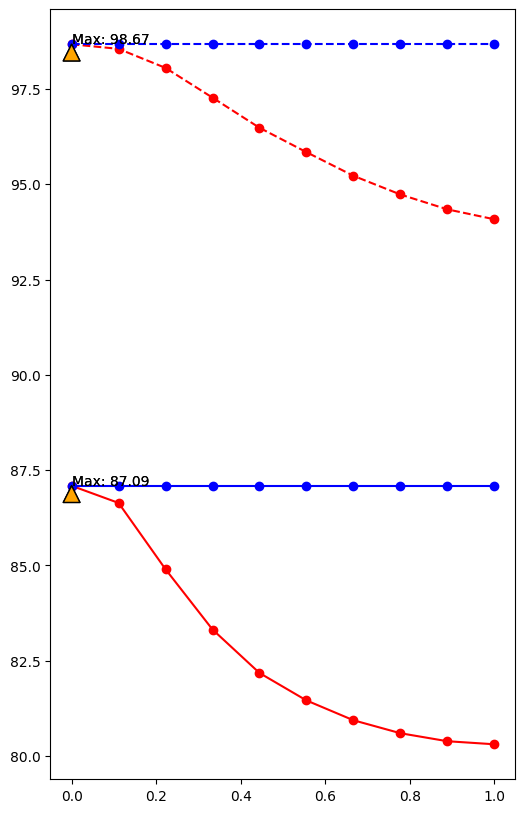

In [ ]:
# Test class 5
acc_EGEM_poisioned_list, acc_EGEM_nonpoisioned_list = test_modified_model(
    model,
    lambda_param_list,
    test_loader,
    test_0poisioned_loader,
    test_class_list=[5],
    c_per_digt_list=c_per_digt_list,
    device=device
)

# acc_EGEM_poisioned
# acc_EGEM_nonpoisioned
# acc_original_poisioned_avgs
# acc_original_0poisioned_avgs

fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_EGEM_poisioned_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_poisioned_list)
max_val = acc_EGEM_poisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_EGEM_nonpoisioned_list, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_nonpoisioned_list)
max_val = acc_EGEM_nonpoisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


plt.show()

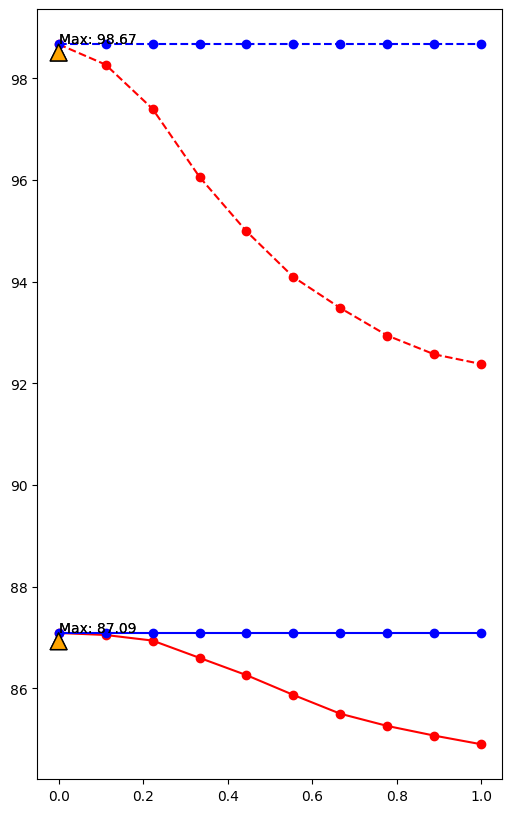

In [ ]:
# Test class 6
acc_EGEM_poisioned_list, acc_EGEM_nonpoisioned_list = test_modified_model(
    model,
    lambda_param_list,
    test_loader,
    test_0poisioned_loader,
    test_class_list=[6],
    c_per_digt_list=c_per_digt_list,
    device=device
)

# acc_EGEM_poisioned
# acc_EGEM_nonpoisioned
# acc_original_poisioned_avgs
# acc_original_0poisioned_avgs

fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_EGEM_poisioned_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_poisioned_list)
max_val = acc_EGEM_poisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_EGEM_nonpoisioned_list, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_nonpoisioned_list)
max_val = acc_EGEM_nonpoisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


plt.show()

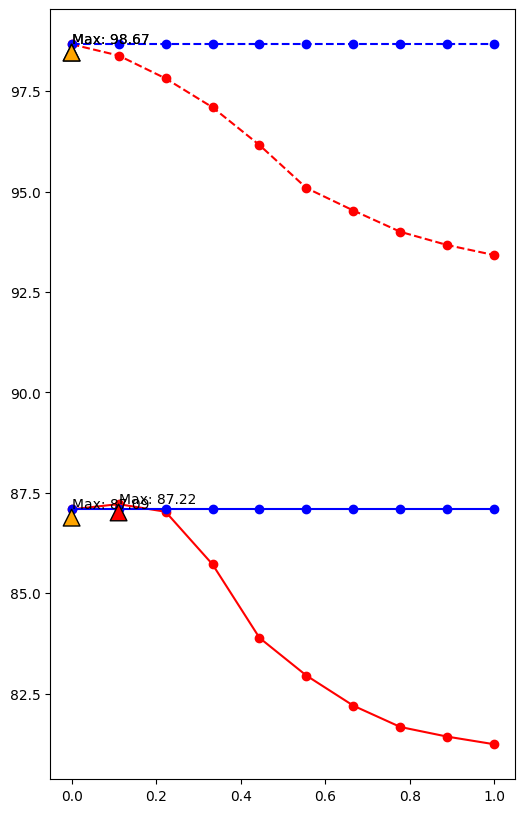

In [ ]:
# Test class 7
acc_EGEM_poisioned_list, acc_EGEM_nonpoisioned_list = test_modified_model(
    model,
    lambda_param_list,
    test_loader,
    test_0poisioned_loader,
    test_class_list=[7],
    c_per_digt_list=c_per_digt_list,
    device=device
)

# acc_EGEM_poisioned
# acc_EGEM_nonpoisioned
# acc_original_poisioned_avgs
# acc_original_0poisioned_avgs

fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_EGEM_poisioned_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_poisioned_list)
max_val = acc_EGEM_poisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_EGEM_nonpoisioned_list, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_nonpoisioned_list)
max_val = acc_EGEM_nonpoisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


plt.show()

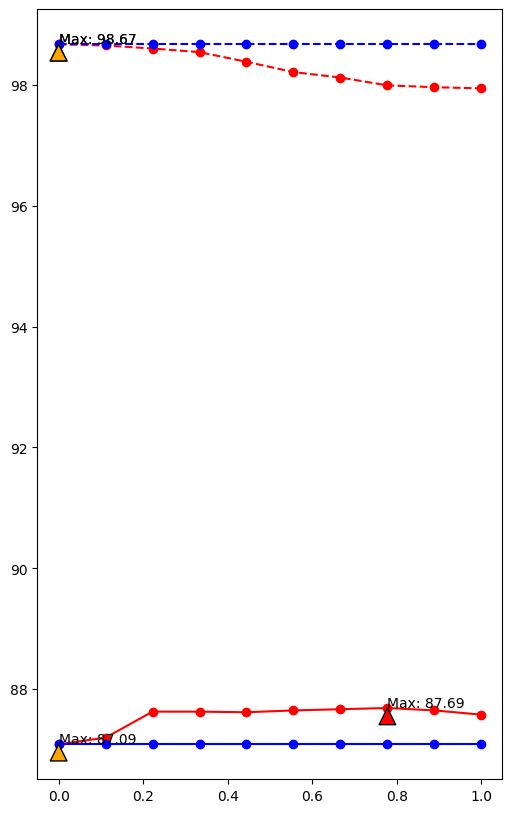

In [ ]:
# Test class 8
acc_EGEM_poisioned_list, acc_EGEM_nonpoisioned_list = test_modified_model(
    model,
    lambda_param_list,
    test_loader,
    test_0poisioned_loader,
    test_class_list=[8],
    c_per_digt_list=c_per_digt_list,
    device=device
)

# acc_EGEM_poisioned
# acc_EGEM_nonpoisioned
# acc_original_poisioned_avgs
# acc_original_0poisioned_avgs

fig, axe_1 = plt.subplots(figsize=(6, 10))


axe_1.plot(lambda_param_list, acc_EGEM_poisioned_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_poisioned_list)
max_val = acc_EGEM_poisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axe_1.plot(lambda_param_list, acc_EGEM_nonpoisioned_list, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_nonpoisioned_list)
max_val = acc_EGEM_nonpoisioned_list[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axe_1.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axe_1.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axe_1.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


plt.show()

## Test EGEM model

In [ ]:
'''
c_per_digt_list: List, 10 elements, depends on the number of lambda
|-c_per_digt: Dict, 10 elements, depends on the number of classes
  |-c_layer1_value: Tensor
  |-c_layer2_value: Tensor
  |-c_fc_value: Tensor
  |-c_fc1_value: Tensor
'''
model = LeNet5(num_classes).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/model_per_digt.pth"))

for i, lambda_param in enumerate(lambda_param_list): # c_8
  modified_model = modified_LeNet5(model, c_per_digt_list[i]).to(device) # Pruning the original model
  # Saving the model parameters
  torch.save(modified_model.state_dict(),
              "/content/drive/MyDrive/Master thesis/EGEM_Model_History/modified_model_per_digt_{}.pth"
              .format(i))

In [ ]:
# The results of class 8 for original model
acc_original_poisioned_avgs = []
acc_original_0poisioned_avgs = []
# The results of rest classes for original model
acc_original_poisioned_avgs.append(test_model(model, test_loader))
acc_original_0poisioned_avgs.append(test_model(model, test_0poisioned_loader))

for i, lambda_param in enumerate(lambda_param_list[:-1]): # c_8
    acc_original_poisioned_avgs.append(acc_original_poisioned_avgs[0])
    acc_original_0poisioned_avgs.append(acc_original_0poisioned_avgs[0])

* acc_EGEM_list: 10 elements, depends on the number of lambda
  * acc_EGEM: the accuracy of EGEM model, combined with 10 different EGEM model
  

In [ ]:
#  Accuracy on nonpoisioned datasets
acc_EGEM_list = []

for i in range(len(lambda_param_list)):
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  #output_per_digt = []

  modified_model = modified_LeNet5(model, c_per_digt_list[i]).to(device)
  modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/modified_model_per_digt_{}.pth".format(i)))

  modified_model.eval()
  with torch.no_grad():
    for image, label in test_loader:
      image = image.to(device)
      label = label.to(device)
      # Getting the outputs from every specific class EGEM forward
      final_output = torch.zeros(image.size(0), num_classes, device=image.device)
      for per_class in range(num_classes):
        output_per_digt = getattr(modified_model, f"forward_EGEM_{per_class}")(image)
        final_output[:, per_class] = output_per_digt[:, per_class]
      # Collecting the accuracy of the final output
      _, predicted = torch.max(final_output.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_EGEM_list.append(acc)
  print("{} done!".format(i))

0 done!
1 done!
2 done!
3 done!
4 done!
5 done!
6 done!
7 done!
8 done!
9 done!


In [ ]:
acc_EGEM_list

[89.68999981880188,
 87.19000220298767,
 89.13999795913696,
 90.2400016784668,
 89.25999999046326,
 85.85000038146973,
 78.329998254776,
 68.80000233650208,
 56.459999084472656,
 44.38999891281128]

In [ ]:
#  Accuracy on nonpoisioned datasets
acc_EGEM_nonpoisioned_list = []

for i in range(len(lambda_param_list)):
  acc = Accuracy(task="multiclass", num_classes=10).to(device)
  #output_per_digt = []

  modified_model = modified_LeNet5(model, c_per_digt_list[i]).to(device)
  modified_model.load_state_dict(torch.load("/content/drive/MyDrive/Master thesis/EGEM_Model_History/modified_model_per_digt_{}.pth".format(i)))

  modified_model.eval()
  with torch.no_grad():
    for image, label in test_0poisioned_loader:
      image = image.to(device)
      label = label.to(device)
      # Getting the outputs from every specific class EGEM forward
      final_output = torch.zeros(image.size(0), num_classes, device=image.device)
      for per_class in range(num_classes):
        output_per_digt = getattr(modified_model, f"forward_EGEM_{per_class}")(image)
        final_output[:, per_class] = output_per_digt[:, per_class]
      # Collecting the accuracy of the final output
      _, predicted = torch.max(final_output.data, 1)
      acc(predicted, label)
  acc = acc.compute()
  acc = acc.item()*100
  acc_EGEM_nonpoisioned_list.append(acc)
  print("{} done!".format(i))

0 done!
1 done!
2 done!
3 done!
4 done!
5 done!
6 done!
7 done!
8 done!
9 done!


In [ ]:
acc_EGEM_nonpoisioned_list

[98.72000217437744,
 98.07000160217285,
 97.25000262260437,
 94.9400007724762,
 90.85999727249146,
 84.78000164031982,
 76.08000040054321,
 65.54999947547913,
 55.86000084877014,
 45.87999880313873]

## Visualisation

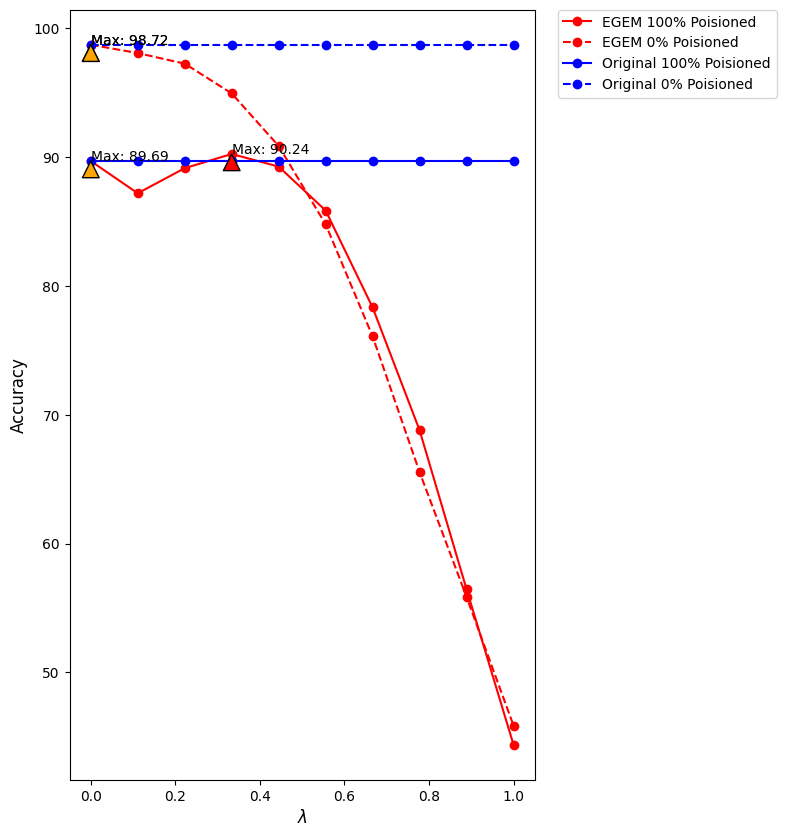

In [ ]:
# acc_EGEM_list
# acc_EGEM_nonpoisioned_list
# acc_original_poisioned_avgs
# acc_original_0poisioned_avgs
fig, axes = plt.subplots(figsize=(6, 10))


axes.plot(lambda_param_list, acc_EGEM_list, linestyle='-', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_list)
max_val = acc_EGEM_list[max_idx]
axes.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))


axes.plot(lambda_param_list, acc_EGEM_nonpoisioned_list, linestyle='--', marker='o', color='red')
max_idx = np.argmax(acc_EGEM_nonpoisioned_list)
max_val = acc_EGEM_nonpoisioned_list[max_idx]
axes.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='red'))

axes.plot(lambda_param_list, acc_original_poisioned_avgs, linestyle='-', marker='o', color='blue')
max_idx = np.argmax(acc_original_poisioned_avgs)
max_val = acc_original_poisioned_avgs[max_idx]
axes.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))


axes.plot(lambda_param_list, acc_original_0poisioned_avgs, linestyle='--', marker='o', color='blue')
max_idx = np.argmax(acc_original_0poisioned_avgs)
max_val = acc_original_0poisioned_avgs[max_idx]
axes.annotate(f'Max: {max_val:.2f}', xy=(lambda_param_list[max_idx], max_val),
                 xytext=(lambda_param_list[max_idx], max_val + 0.02),
                 arrowprops=dict(facecolor='orange'))

axes.set_xlabel("$\lambda$", fontsize=12)
axes.set_ylabel("Accuracy", fontsize=12)
axes.legend(["EGEM 100% Poisioned", "EGEM 0% Poisioned", "Original 100% Poisioned", "Original 0% Poisioned"],
       bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)# Place the legend outside the plot, aligned with the top of the plot

plt.show()